In [1]:
import networkx as nx
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import time
import ast
from collections import Counter
import warnings
import os
import re

In [3]:
from mytools import extract_hours, visualize_dag, pert_sample, draw_random_durations, compute_times, find_critical_path, simulation

In [4]:
sns.set_theme()

## Project

In [5]:
project_name='C2018-13-Christmas-market'
file_path='dataset/C2018-13 Christmas market.xlsx'
Nca=37 # Number of control accounts (tracking points)
risk='Yes'

## Baseline schedule

In [6]:
# Read the baseline schedule
with warnings.catch_warnings():
    warnings.simplefilter("ignore", UserWarning)
    df=pd.read_excel(file_path, sheet_name='Baseline Schedule',skiprows=1,index_col=0,usecols='A:N')
df.drop(0,axis=0,inplace=True) # drop the first row
df.drop(df[df['Successors'].isna() & df['Predecessors'].isna()].index,axis=0,inplace=True) # drop the rows with NaN successors and predecessors that not correspond to any activity
df['DurationH']=df['Duration'].apply(lambda x: extract_hours(x)) # extract the duration in hours
df_project=df[['Name', 'Successors', 'DurationH', 'Total Cost']].copy()
df_project.columns=['Name', 'Successors', 'Duration', 'TotalCost']

In [7]:
# Read the risk analysis and merge with the project dataframe
if risk is not None:
    df=pd.read_excel(file_path, sheet_name='Risk Analysis',skiprows=1,usecols=range(7),index_col=0)
    df.drop(0,axis=0,inplace=True) # drop the first row
    df_project=pd.merge(df_project,df[['Optimistic', 'Most Probable','Pessimistic']],left_index=True,right_index=True)
else:
    # Assume a skewed left distribution for the risk
    df_project['Optimistic']=80
    df_project['Most Probable']=110
    df_project['Pessimistic']=120

# Compute the optimistic, most probable, and pessimistic durations in hours
df_project['OptimisticH']=df_project['Optimistic']*df_project['Duration']/100
df_project['MostProbableH']=df_project['Most Probable']*df_project['Duration']/100
df_project['PessimisticH']=df_project['Pessimistic']*df_project['Duration']/100

# Drop the original Optimistic, Most Probable, and Pessimistic columns
df_project.drop(['Optimistic', 'Most Probable','Pessimistic'],axis=1,inplace=True)

# Rename the columns
df_project.columns=['Name', 'Successors', 'Duration', 'TotalCost', 'Optimistic', 'MostProbable', 'Pessimistic']

In [8]:
# Build the Activity on Node (AON) network
# The activity‐on‐node (AON) network is modeled as a Networkx directed acyclic 
Go=nx.DiGraph()
for i in df_project.index:
    mean_d=(df_project.loc[i,'Optimistic']+4*df_project.loc[i,'MostProbable']+df_project.loc[i,'Pessimistic'])/6
    Go.add_node(i,
               planned_value = df_project.loc[i,'TotalCost'], # The planned value
               optimistic = df_project.loc[i,'Optimistic'], # The optimistic duration
               pessimistic = df_project.loc[i,'Pessimistic'], # The pessimistic duration
               mostlikely = df_project.loc[i,'MostProbable'], # The most likely duration
               mean_duration=mean_d) # The mean duration
    if not pd.isna(df_project.loc[i,'Successors']):
        for s in df_project.loc[i,'Successors'].split(";"):
            Go.add_edge(i,int(s[2:]),type=s[:2])
print(f'AON graph with {Go.number_of_nodes()} nodes and {Go.number_of_edges()} edges')
print('Is a directed aclyclic grapk',nx.is_directed_acyclic_graph(Go))  

AON graph with 33 nodes and 45 edges
Is a directed aclyclic grapk True


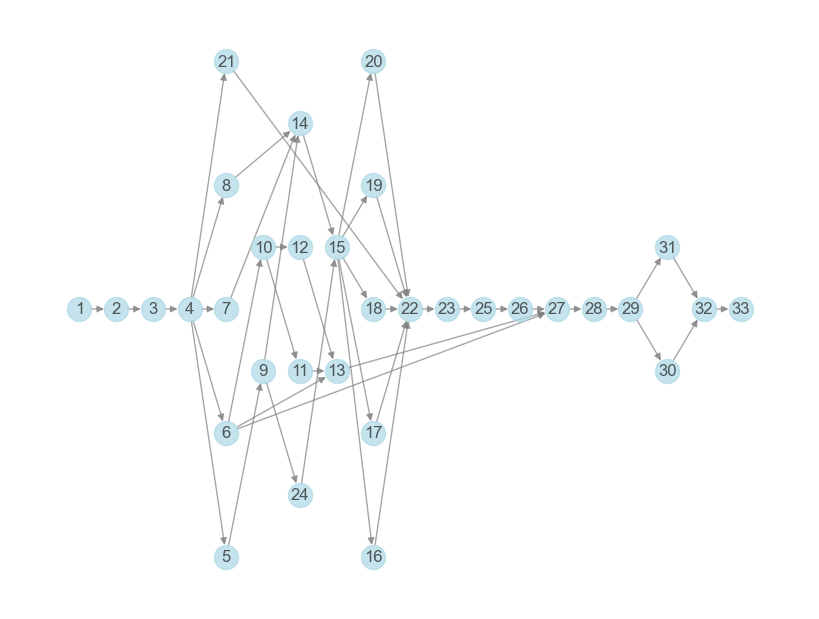

In [9]:
# Visualize the AON network
visualize_dag(Go)

## Contol Accounts

### Simulation of all control accounts

In [10]:
Ns=1000 # Number of simulation runs

In [11]:
# Simulations from CA !!!!!!!!
start_time = time.time()
for tp in range(Nca+1):
    
    if tp==0: # Baseline schedule
        print('Simulation for the baseline schedule ...')
        simulation(Go.copy(),project_name,experiment='tp0_ev0',control=None,Nruns=Ns)
    else:
        # Read the control account data
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", UserWarning)
            df=pd.read_excel(file_path, sheet_name='TP'+str(tp),skiprows=3,index_col=0)
        ev_percent=df.loc[0,'Percentage Completed'] # Read the EV%
        dfc=df.loc[df.index.intersection(Go.nodes()),['Actual Duration', 'Actual Cost','Percentage Completed', 'Earned Value (EV)', 'Planned Value (PV)']].copy()
        dfc['Actual Duration']=dfc['Actual Duration'].apply(lambda x: extract_hours(x)) # extract the duration in hours
        dfc.columns=['ActualDuration', 'ActualCost', 'PercentageCompleted', 'EarnedValue', 'PlannedValue'] # rename the columns

        # Simulations from CA
        print('Simulation for TP'+str(tp)+' ...')
        simulation(Go.copy(),project_name,experiment='tp'+str(tp)+"_ev" +str(round(ev_percent,4)),control=dfc,Nruns=Ns)
print(f"Monte Carlo Simulation took {time.time() - start_time} seconds to run {(Nca+1)*Ns} samples")


Simulation for the baseline schedule ...
Simulation for TP1 ...
Simulation for TP2 ...
Simulation for TP3 ...
Simulation for TP4 ...
Simulation for TP5 ...
Simulation for TP6 ...
Simulation for TP7 ...
Simulation for TP8 ...
Simulation for TP9 ...
Simulation for TP10 ...
Simulation for TP11 ...
Simulation for TP12 ...
Simulation for TP13 ...
Simulation for TP14 ...
Simulation for TP15 ...
Simulation for TP16 ...
Simulation for TP17 ...
Simulation for TP18 ...
Simulation for TP19 ...
Simulation for TP20 ...
Simulation for TP21 ...
Simulation for TP22 ...
Simulation for TP23 ...
Simulation for TP24 ...
Simulation for TP25 ...
Simulation for TP26 ...
Simulation for TP27 ...
Simulation for TP28 ...
Simulation for TP29 ...
Simulation for TP30 ...
Simulation for TP31 ...
Simulation for TP32 ...
Simulation for TP33 ...
Simulation for TP34 ...
Simulation for TP35 ...
Simulation for TP36 ...
Simulation for TP37 ...
Monte Carlo Simulation took 206.97468280792236 seconds to run 38000 samples


### Crritical index and histograms of actual durations for all CA

In [12]:
# Read the simulation files !!!!!!!
siml=[file for file in os.listdir("./data/"+project_name) if ('simulation_'+project_name+'_tp') in file]
siml=[(int(re.search(r'tp(\d+)', file).group(1)), re.search(r'ev([\d.]+)', file).group(1)[:-1],file) for file in siml] 
siml=sorted(siml,key=lambda x: x[0])

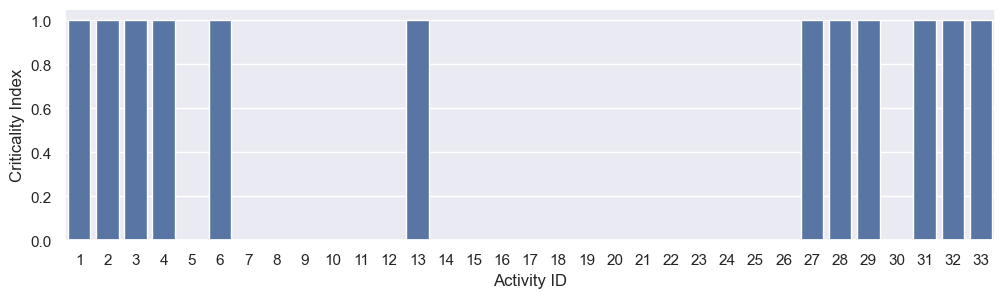

In [13]:
# Criticality index of activities
data=siml[0] # Baseline schedule
df_sim=pd.read_csv('./data/'+project_name+'/'+data[2])
N=df_sim.shape[0] # Number of samples
criticality_index={n:0 for n in Go.nodes()}
for i,v in Counter(df_sim['critical_path'].apply(lambda x: ast.literal_eval(x)).sum()).items():
    criticality_index[i]=v/N
g=sns.barplot(x=list(criticality_index.keys()), y=list(criticality_index.values()))
g.set_xlabel('Activity ID')
g.set_ylabel('Criticality Index')
g.figure.set_size_inches(12,3)

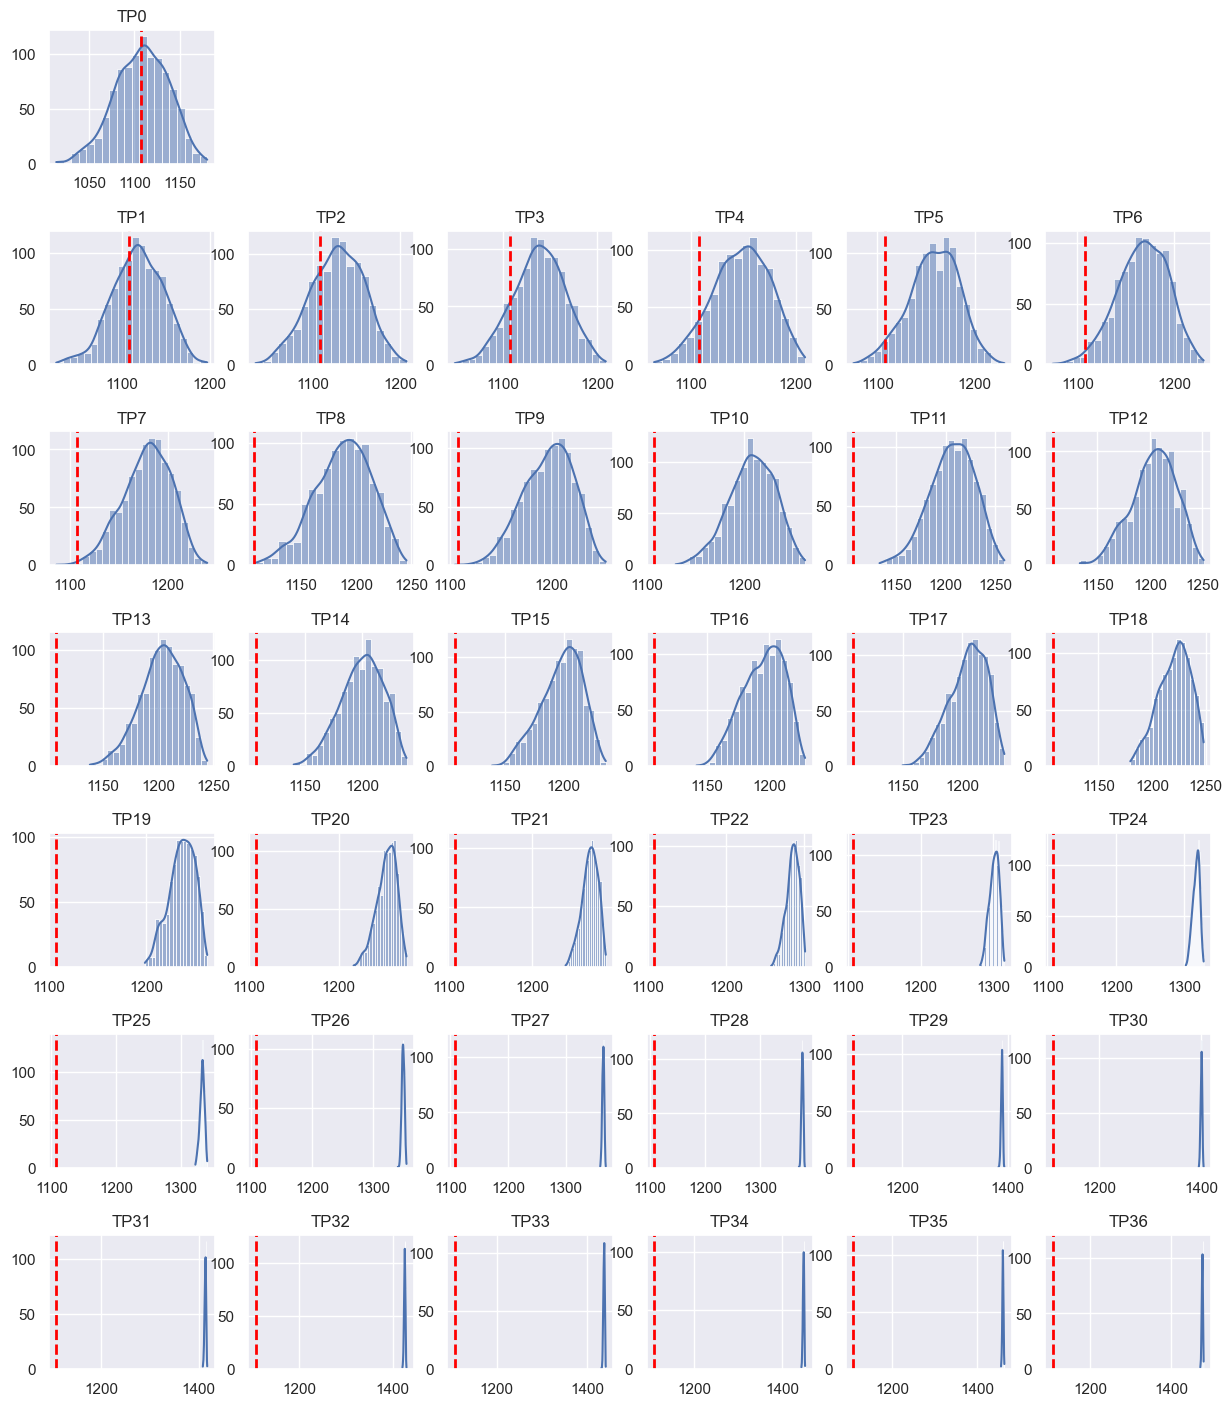

In [14]:
# Plot the histograms
Nr=Nca//6+2
Nc=6
plt.figure(figsize=(Nc*2.5,Nr*2.5))

data=siml[0] # Baseline schedule
df_sim=pd.read_csv('./data/'+project_name+'/'+data[2])
tp = data[0]
ev = data[1]
plt.subplot(Nr,Nc,1)
g=sns.histplot(df_sim['actual_duration'],kde=True)
plt.axvline(x=df_sim.loc[0,'baseline_duration'], color='red', linestyle='--', linewidth=2,label='Baseline duration')
g.set_xlabel('')
g.set_ylabel('')
g.set_title('TP'+str(tp))

for i,data in enumerate(siml):
    if (i>0) and (i<Nca): # skip the baseline schedule and the last control account
        df_sim=pd.read_csv('./data/'+project_name+'/'+data[2])
        tp = data[0]
        ev = data[1]
        plt.subplot(Nr,Nc, i+6)
        g=sns.histplot(df_sim['actual_duration'],kde=True)
        plt.axvline(x=df_sim.loc[0,'baseline_duration'], color='red', linestyle='--', linewidth=2,label='Baseline duration')
        g.set_xlabel('')
        g.set_ylabel('')
        g.set_title('TP'+str(tp))

plt.subplots_adjust(hspace=0.5)
